# 4. Analysis — Aggregate Results & Visualize

Load results from each experiment stage and produce comparison plots.

> Set `STAGE_TO_ANALYZE` to match the stage you want to visualize.

In [1]:
# ============================================================
# Cell 1 — Configuration
# ============================================================
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style='whitegrid', font_scale=1.1)

# Which stage to analyze: 'feature' | 'model' | 'instrument'
STAGE_TO_ANALYZE = 'feature'

OUTPUT_DIR = Path('./outputs')

In [2]:
# ============================================================
# Cell 2 — Load Results
# ============================================================
json_file = OUTPUT_DIR / f'results_stage_{STAGE_TO_ANALYZE}.json'
pkl_file = OUTPUT_DIR / f'results_stage_{STAGE_TO_ANALYZE}_full.pkl'

with open(json_file, 'r') as f:
    results_json = json.load(f)

rdf = pd.DataFrame(results_json)
display(rdf[['model', 'instrument', 'feature', 'best_val_acc', 'final_train_loss']])

# Load full history if available
full_results = None
if pkl_file.exists():
    with open(pkl_file, 'rb') as f:
        full_results = pickle.load(f)
    print(f'Full history loaded ({len(full_results)} experiments)')

,model,instrument,feature,best_val_acc,final_train_loss
0,lstm,raw_audio,mfcc,0.254230,1.731111
1,lstm,raw_audio,chromagram,0.362425,1.197999
2,lstm,raw_audio,mfcc_chroma,0.260582,1.121022


Full history loaded (3 experiments)


/var/folders/w8/37n9094n1x7_cgq0g3nt7vsr0000gn/T/ipykernel_89700/4043011047.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rdf, x=x_col, y='best_val_acc', ax=ax,


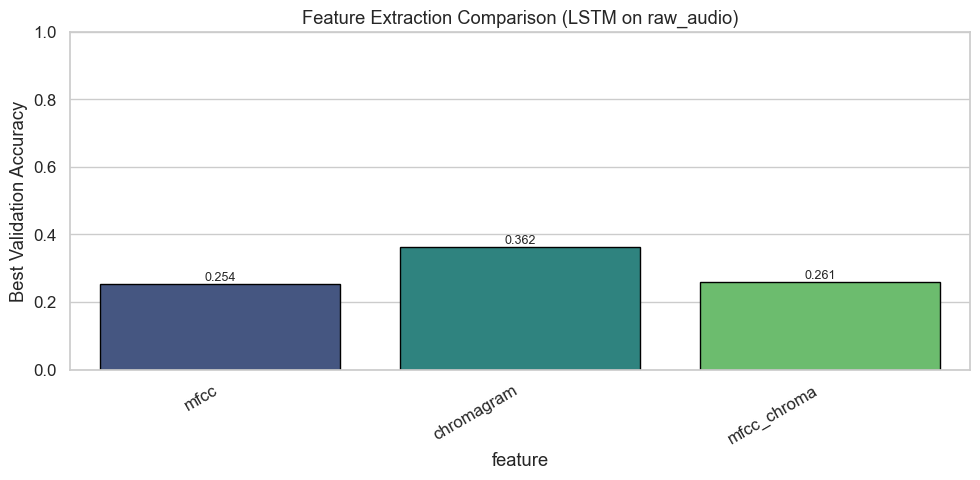

In [3]:
# ============================================================
# Cell 3 — Bar Chart: Best Validation Accuracy
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

if STAGE_TO_ANALYZE == 'feature':
    x_col, title = 'feature', 'Feature Extraction Comparison (LSTM on raw_audio)'
elif STAGE_TO_ANALYZE == 'model':
    x_col, title = 'model', 'Model Architecture Comparison'
elif STAGE_TO_ANALYZE == 'instrument':
    x_col, title = 'instrument', 'Instrument / Stem Comparison'

sns.barplot(data=rdf, x=x_col, y='best_val_acc', ax=ax,
            palette='viridis', edgecolor='black')
ax.set_title(title)
ax.set_ylabel('Best Validation Accuracy')
ax.set_ylim(0, 1)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'bar_{STAGE_TO_ANALYZE}.png', dpi=150)
plt.show()

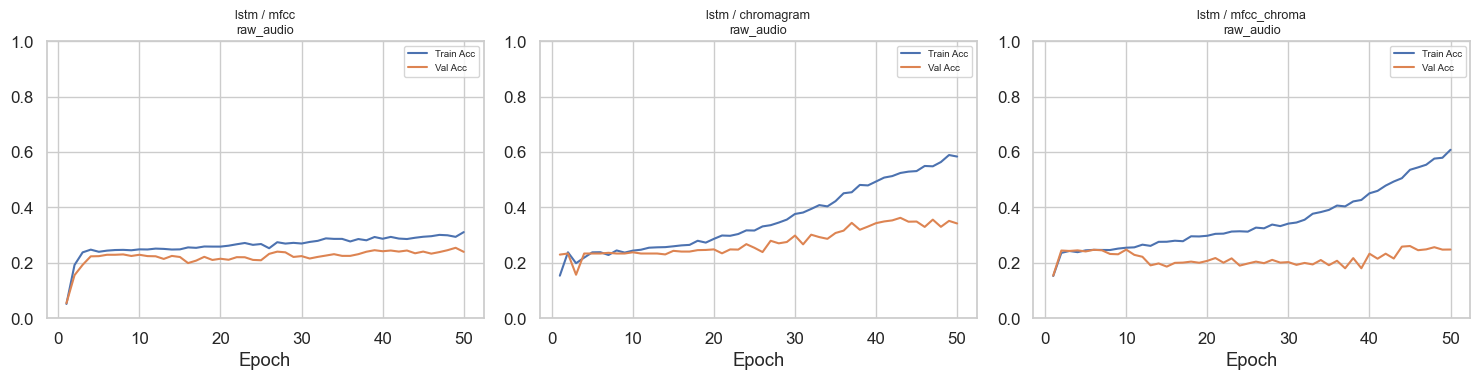

In [4]:
# ============================================================
# Cell 4 — Training Curves
# ============================================================
if full_results:
    n_exp = len(full_results)
    fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 4), squeeze=False)

    for i, r in enumerate(full_results):
        ax = axes[0][i]
        h = r['history']
        epochs = range(1, len(h['train_loss'])+1)
        ax.plot(epochs, h['train_acc'], label='Train Acc')
        ax.plot(epochs, h['val_acc'], label='Val Acc')
        ax.set_title(f"{r['model']} / {r.get('feature','')}\n{r.get('instrument','')}", fontsize=9)
        ax.set_xlabel('Epoch')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'curves_{STAGE_TO_ANALYZE}.png', dpi=150)
    plt.show()
else:
    print('Full history not available (pkl file missing).')

In [5]:
# ============================================================
# Cell 5 — Cross-Stage Summary (run after all 3 stages)
# ============================================================
all_stages = []
for stage in ['feature', 'model', 'instrument']:
    p = OUTPUT_DIR / f'results_stage_{stage}.json'
    if p.exists():
        with open(p) as f:
            data = json.load(f)
        for row in data:
            row['stage'] = stage
        all_stages.extend(data)

if all_stages:
    summary = pd.DataFrame(all_stages)
    print('=== Cross-Stage Summary ===')
    display(summary[['stage', 'model', 'instrument', 'feature', 'best_val_acc']].sort_values('best_val_acc', ascending=False))
else:
    print('No results found yet. Run modeling stages first.')

=== Cross-Stage Summary ===


,stage,model,instrument,feature,best_val_acc
11,instrument,transformer,guitar_piano_bass,chromagram,0.648462
12,instrument,transformer,no_vocals,chromagram,0.609620
10,instrument,transformer,guitar_piano,chromagram,0.569545
14,instrument,transformer,raw_audio,chromagram,0.428538
7,model,transformer,raw_audio,chromagram,0.424682
6,model,bilstm,raw_audio,chromagram,0.421987
9,instrument,transformer,guitar,chromagram,0.419001
5,model,lstm,raw_audio,chromagram,0.418974
13,instrument,transformer,piano,chromagram,0.417625
4,model,gru,raw_audio,chromagram,0.385510
